In [3]:
import sys, os
import glob

# ── CONFIG ──────────────────────────────────────────────────────────────────
REPO_ROOT = os.path.abspath("..")
IMAGE_DIR  = os.path.join(REPO_ROOT, "data", "scratch")
OUTPUT_DIR = os.path.join(REPO_ROOT, "output")

METHOD = "ORB" #'ORB' or 'SIFT'
RATIO_THRESH = 0.75

# RANSAC reprojection error (pixels)
RANSAC_THRESH = 4.0
FEATHER = 40
# ────────────────────────────────────────────────────────────────────────────

sys.path.insert(0, os.path.join(REPO_ROOT, "src"))
os.makedirs(OUTPUT_DIR, exist_ok=True)

import cv2
import numpy as np
import glob
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display

# Pipeline modules
from stitching.feature    import detect_and_describe, preprocess_image
from stitching.matcher    import match_features, visualize_matches
from stitching.homography import compute_homography, warp_and_place
from stitching.blender    import blend_images, crop_black_borders
from stitching.pipeline   import stitch_images, stitch_pair


# ── Helper: display an image inline ─────────────────────────────────────────
def show(img, title="", cmap=None, figsize=(12, 6)):
    """Display a BGR or grayscale image inline with matplotlib."""
    plt.figure(figsize=figsize)
    if img.ndim == 3:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap=cmap or "gray")
    plt.title(title, fontsize=13)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

def show_grid(images, titles=None, cols=3, figsize=(16, 9)):
    """Display multiple images in a grid."""
    n = len(images)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).flatten()
    for i, ax in enumerate(axes):
        if i < n:
            img = images[i]
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if img.ndim == 3 else img, cmap="gray")
            ax.set_title(titles[i] if titles else f"Image {i}", fontsize=10)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


   Loaded: 1.jpg  4033×2803 px
   Loaded: 2.jpg  4033×2803 px

✅ 2 image(s) loaded


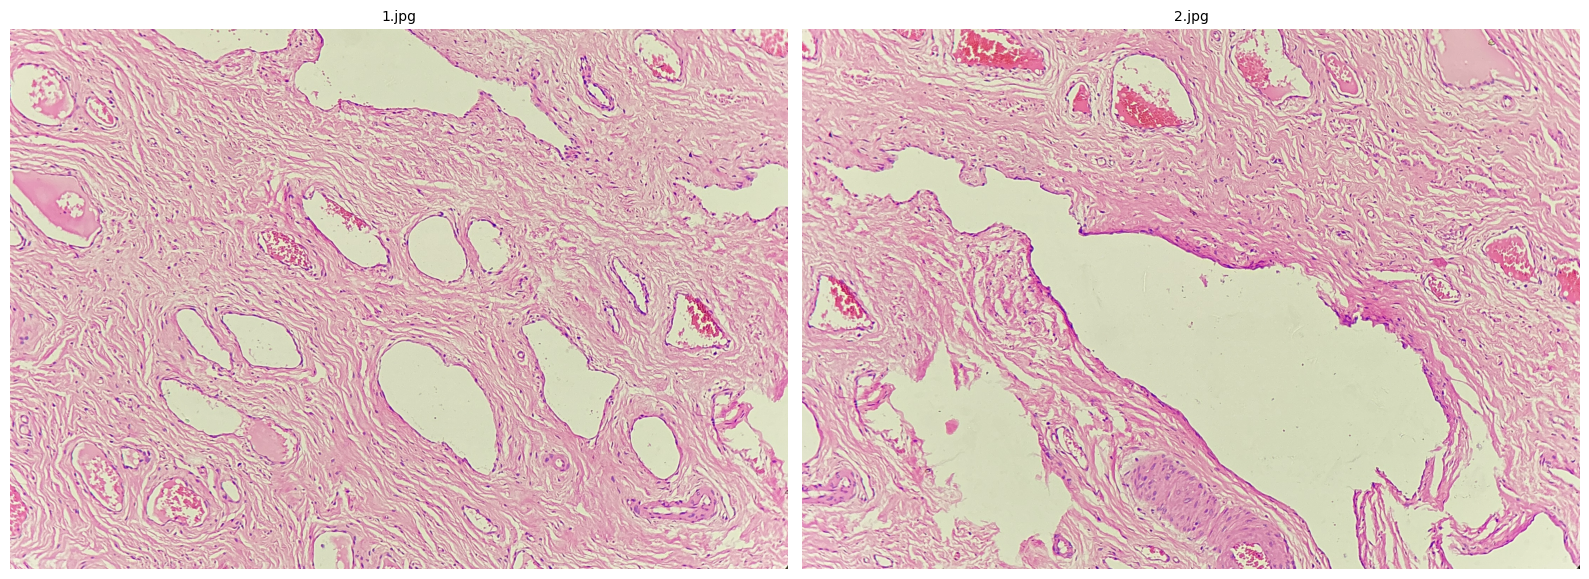

In [4]:
exts = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.JPG", "*.JPEG", "*.PNG")
paths = sorted({p for ext in exts for p in glob.glob(os.path.join(IMAGE_DIR, ext))})

if not paths:
    print(f"⚠️  No images found in: {IMAGE_DIR}")
    print("   → Place overlapping JPEGs there and re-run this cell.")
else:
    images = []
    for p in paths:
        img = cv2.imread(p)
        if img is not None:
            images.append(img)
            print(f"   Loaded: {os.path.basename(p)}  {img.shape[1]}×{img.shape[0]} px")

    print(f"\n✅ {len(images)} image(s) loaded")
    show_grid(images, [os.path.basename(p) for p in paths], cols=min(3, len(images)))


In [6]:

kp_a, des_a = detect_and_describe(images[0], method=METHOD)
kp_b, des_b = detect_and_describe(images[1], method=METHOD)

print(f"Keypoints → A: {len(kp_a)}  |  B: {len(kp_b)}")
print(f"Descriptor shape → {des_a.shape}")


Keypoints → A: 2000  |  B: 2000
Descriptor shape → (2000, 32)
